# Comparison with LIFE X (Carrion-Gonzalez et al. 2023)

Apply LIFE X's definitions (M_p < 5 M_E, per-star Kopparapu HZ, d <= 20 pc, NEA-confirmed) to our enriched HPIC + Exo-MerCat catalogue and compare against the 13 named rocky HZ planets in [LIFE X](https://www.aanda.org/articles/aa/full_html/2023/10/aa47027-23/aa47027-23.html).

Follow-ups in this notebook: investigate why tau Cet e fails the LIFE cut, implement SIMBAD-`*` + Bayer-`01` name normalisation with a collision audit, and add a flux-uncertainty (interval) variant of the cut.


## Part 1 -- Setup

Shared HPIC + Exo-MerCat crossmatch and enrichment.

In [1]:
%load_ext autoreload
%autoreload 2

import glob, os, pathlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.table import Table

# Project root, whether the kernel cwd is the repo root or literatureComparison/
ROOT = pathlib.Path.cwd()
if not (ROOT / 'crossmatching').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

from crossmatching import (Crossmatcher, EMCCatalog, EMCIdSupplier, rocky_mask, temperate_mask)
from crossmatching.enrichment import (
    HpicParamSource, NeaParamSource, SimbadParamSource, EuParamSource,
    EpicParamSource, ToiParamSource, ParamFiller
)
from crossmatching.enrichment import classify_spectral_type, teff_to_spectype

mpl.rcParams['figure.dpi'] = 300

CATEGORY_ORDER  = ['Sun-like', 'Low-luminosity', 'Very-low-luminosity', 'Other']
CATEGORY_COLORS = {
    'Sun-like':            '#F5A623',
    'Low-luminosity':      '#E05C00',
    'Very-low-luminosity': '#C0392B',
    'Other':               '#95A5A6',
}

rjup_to_rearth = u.R_jup.to(u.R_earth)
mjup_to_mearth = u.M_jup.to(u.M_earth)

In [2]:
os.getcwd()

'/home/joshuadreier/Documents/CodingProjects/SemesterProjectEHG'

In [3]:
input_table = Table.read('input/HPIC_LC4_combined_d50.txt', format='ascii')
cme = Crossmatcher(EMCCatalog(), EMCIdSupplier())
cme.load_catalog(from_file='exo-mercat.csv', format='csv')
cme.load_alternate_ids(input_table['star_name'].tolist(), from_file='exo-mercat.csv')
input_table = cme.remove_duplicates(input_table, input_starname_key='star_name')
out_emc = cme.combined_crossmatch(input_table, input_starname_key='star_name')
print(f'HPIC stars: {len(input_table):,}   crossmatched planet rows: {len(out_emc):,}')

HPIC stars: 14,559   crossmatched planet rows: 1,260


In [4]:
# ── Tier 1: NEA (pscomppars) ──────────────────────────────────────────────────
nea_src = NeaParamSource()
nea_src.load(from_file='./pscomppars.txt', format='ascii')
print(f'NEA planets loaded:     {len(nea_src._lookup):,}')
print(f'With insol:             {sum(1 for v in nea_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in nea_src._lookup.values() if "teff" in v and "rad" in v):,}')


# Tier 3
eu_src = EuParamSource()
eu_path = sorted(glob.glob('../Exo-MerCat/InputSources/eu_init*.csv'))[-1]
eu_src.load(from_file=eu_path, format="ascii.csv")
print(f"\nEU planets loaded: {len(eu_src._lookup):,}")

# ── Tier 2: EPIC (K2 planets not in NEA) ─────────────────────────────────────
epic_src = EpicParamSource()
epic_path = sorted(glob.glob('../Exo-MerCat/InputSources/epic_init*.csv'))[-1]
epic_src.load(from_file=epic_path, format='ascii.csv')
print(f'\nEPIC planets loaded:    {len(epic_src._lookup):,}')
print(f'With insol:             {sum(1 for v in epic_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in epic_src._lookup.values() if "teff" in v and "rad" in v):,}')

# ── Tier 3: TOI (TESS objects) ────────────────────────────────────────────────
toi_src = ToiParamSource()
toi_path = sorted(glob.glob('../Exo-MerCat/InputSources/toi_init*.csv'))[-1]
toi_src.load(from_file=toi_path, format='ascii.csv')
print(f'\nTOI entries loaded:     {len(toi_src._lookup):,}')
print(f'With insol:             {sum(1 for v in toi_src._lookup.values() if "insol" in v):,}')
print(f'With teff + rad:        {sum(1 for v in toi_src._lookup.values() if "teff" in v and "rad" in v):,}')

# ── Tier 4: SIMBAD fallback ───────────────────────────────────────────────────
simbad_src = SimbadParamSource()
simbad_src.load(from_file='simbad_params.txt')

merger = ParamFiller([nea_src, eu_src, epic_src, toi_src, simbad_src, hpic_src])
e_emc  = merger.enrich(
    cme.catalog_table,
    input_starname_key="star_name", 
    id_supplier=cme.id_supplier, 
    alternate_ids=cme.alternate_ids,
    **EMCCatalog.ENRICH_KEYS
)


full_emc   = cme.catalog_table
nasa_names = [str(n).strip() for n in full_emc['nasa_name']]
nea_keys   = set(nea_src._lookup)
has_nea    = np.array([n in nea_keys for n in nasa_names])

for t in (full_emc, out_emc):
    t['r_earth']     = t['r'] * rjup_to_rearth
    t['mass_earth']  = t['bestmass'] * mjup_to_mearth
    t['msini_earth'] = t['msini'] * mjup_to_mearth

print(f'enriched full_emc: {len(full_emc):,}   enriched out_emc: {len(out_emc):,}')

NEA planets loaded:     6,298
With insol:             4,413
With teff + rad:        5,977

EU planets loaded: 11,159

EPIC planets loaded:    1,806
With insol:             175
With teff + rad:        1,230

TOI entries loaded:     7,931
With insol:             7,752
With teff + rad:        7,394


NameError: name 'hpic_src' is not defined

### Helpers

- `kopparapu_seff(teff, coeffs)` -- Teff-dependent HZ insolation limit (Kopparapu+ 2013/14).
- `normalize_name(s)` -- cross-catalog match key. Strips SIMBAD `* ` prefix and 2-digit Bayer suffix (`alf01 Cen` -> `alf Cen`); preserves binary component letters.
- `clean_name(s)` -- display-friendly cleaner (whitespace + placeholders).
- `category_from_teff(teff)` -- map Teff to our `spectral_category` so paper samples sit in the same bins as our own classification.


In [ ]:
# Kopparapu et al. 2013 (erratum 2014) -- optimistic bounds
KOPP_RECENT_VENUS = (1.776, 2.136e-4, 2.533e-8, -1.332e-11, -3.097e-15)
KOPP_EARLY_MARS   = (0.320, 5.547e-5, 1.526e-9, -2.874e-12, -5.011e-16)

def kopparapu_seff(teff, coeffs):
    s0, a, b, c, d = coeffs
    ts = np.clip(np.asarray(teff, dtype=float), 2600.0, 7200.0) - 5780.0
    return s0 + a*ts + b*ts**2 + c*ts**3 + d*ts**4

import re
_BAYER_PREFIX = re.compile(r'^(alf|bet|gam|del|eps|zet|eta|tet|iot|kap|lam|mu|nu|xi|omi|pi|rho|sig|tau|ups|phi|chi|psi|ome)(0\d)\b', re.IGNORECASE)

def normalize_name(s):
    """Cross-catalog name match key. Strips SIMBAD '*' prefix and 2-digit suffix
    on lowercase Bayer letters ('alf01 Cen' -> 'alf Cen'). Component letters (A, B)
    are preserved, so binary components do not merge."""
    if s is None:
        return ''
    t = ' '.join(str(s).split())
    if t in ('', '--', 'nan', 'None', '0'):
        return ''
    if t.startswith('* '):
        t = t[2:]
    t = _BAYER_PREFIX.sub(lambda m: m.group(1), t)
    return t.casefold()

def clean_name(v):
    """Display-friendly cleaner: collapses whitespace, returns '' for placeholders."""
    s = ' '.join(str(v).split())
    return '' if s in ('', '--', 'nan', 'None', '0') else s

def category_from_teff(teff):
    sp = teff_to_spectype(teff).lstrip('~')
    return classify_spectral_type(sp) if sp else 'Other'

# Convenience views on the enriched full_emc table
teff_fc = np.ma.filled(np.ma.asarray(full_emc['st_teff'], float),   np.nan)
flux_fc = np.ma.filled(np.ma.asarray(full_emc['flux_rel'], float),  np.nan)
rade_fc = np.ma.filled(np.ma.asarray(full_emc['r_earth'], float),   np.nan)
bmasse_fc = np.ma.filled(np.ma.asarray(full_emc['mass_earth'], float), np.nan)
msinie_fc = np.ma.filled(np.ma.asarray(full_emc['msini_earth'], float), np.nan)
dist_fc = np.ma.filled(np.ma.asarray(full_emc['sy_dist'], float),   np.nan)
status_fc = np.array([str(s) for s in full_emc['status']])
conf_fc   = status_fc == 'CONFIRMED'
cats_fc   = np.array(full_emc['spectral_category'])

nasa_fc = np.array([clean_name(v) for v in full_emc['nasa_name']])
emcn_fc = np.array([clean_name(v) for v in full_emc['exo-mercat_name']])
name_fc = np.where(nasa_fc != '', nasa_fc, emcn_fc)
# Match key: try NASA name first; fall back to EMC name
name_key_fc = np.array([
    normalize_name(nasa_fc[i]) or normalize_name(emcn_fc[i])
    for i in range(len(full_emc))
])

# Flux error arrays for interval-based HZ tests
flux_err1_fc = np.ma.filled(np.ma.asarray(full_emc['flux_rel_err1'], float), 0.0)
flux_err2_fc = np.ma.filled(np.ma.asarray(full_emc['flux_rel_err2'], float), 0.0)
flux_err1_fc[~np.isfinite(flux_err1_fc)] = 0.0
flux_err2_fc[~np.isfinite(flux_err2_fc)] = 0.0

print(f'flux_rel valid:  {np.isfinite(flux_fc).sum():,}/{len(full_emc):,}')
print(f'st_teff valid:   {np.isfinite(teff_fc).sum():,}/{len(full_emc):,}')
print(f'r_earth defined: {(rade_fc > 0).sum():,}   bestmass defined: {(bmasse_fc > 0).sum():,}'
      f'   msini defined: {(msinie_fc > 0).sum():,}')


KeyError: 'st_teff'

## Part 3 -- Compare with LIFE X (Carrion-Gonzalez et al. 2023)

**LIFE X working definitions** (their Section 3.1):

- **Rocky proxy** = `M_p < 5 M_E` (they group LIFE-detectable HZ planets by M_p, not radius).
- **HZ** = Kopparapu 2014, optimistic (`Recent Venus / Early Mars`) -- same as Bohl, per-star.
- **Sample** = NEA confirmed planets, snapshot 2022-11-06, distance cut 20 pc for LIFE's sensitivity.
- **Their headline list of 13 named M_p < 5 M_E HZ planets detectable by LIFE** (their Section 3.1 + Appendix E):
  `tau Cet e, GJ 667 C c, GJ 667 C e, GJ 667 C f, Teegarden's Star b, Teegarden's Star c, Ross 128 b, GJ 273 b, Ross 508 b, Wolf 1061 c, Proxima Cen b, GJ 3323 b, GJ 1061 d`.

We (a) apply the LIFE X cut to our enriched catalog within 20 pc, (b) check overlap with their 13-planet list, (c) note differences (newer NEA snapshot, EMC vs NEA, Gaia DR3 update).

In [ ]:
# 13 currently-known M_p < 5 M_E HZ planets named in LIFE X Section 3.1
LIFE_X_LIST = [
    'tau Cet e',
    'GJ 667 C c', 'GJ 667 C e', 'GJ 667 C f',
    "Teegarden's Star b", "Teegarden's Star c",
    'Ross 128 b',
    'GJ 273 b',
    'Ross 508 b',
    'Wolf 1061 c',
    'Proxima Cen b',
    'GJ 3323 b',
    'GJ 1061 d',
]
print(f'LIFE X named M_p < 5 M_E HZ planets: {len(LIFE_X_LIST)}')
for n in LIFE_X_LIST:
    print(f'  {n}')

LIFE X named M_p < 5 M_E HZ planets: 13
  tau Cet e
  GJ 667 C c
  GJ 667 C e
  GJ 667 C f
  Teegarden's Star b
  Teegarden's Star c
  Ross 128 b
  GJ 273 b
  Ross 508 b
  Wolf 1061 c
  Proxima Cen b
  GJ 3323 b
  GJ 1061 d


In [ ]:
# Apply LIFE X's definitions to our enriched EMC catalog within 20 pc.
# Rocky:  M_p (true mass) < 5 M_E when available, else msini < 5 M_E. Direct radius is informational only.
# HZ:     per-star Kopparapu Recent Venus / Early Mars (= same as Bohl empirical HZ).
# Status: confirmed only.

rade_valid_fc  = np.isfinite(rade_fc) & (rade_fc > 0)
msini_valid_fc = np.isfinite(msinie_fc) & (msinie_fc > 0)

M5_fc = np.where(
    np.isfinite(bmasse_fc) & (bmasse_fc > 0),
    bmasse_fc < 5.0,
    msini_valid_fc & (msinie_fc < 5.0),
)

sin_fc  = kopparapu_seff(teff_fc, KOPP_RECENT_VENUS)
sout_fc = kopparapu_seff(teff_fc, KOPP_EARLY_MARS)
flux_valid_fc = np.isfinite(flux_fc) & np.isfinite(teff_fc)
hz_kopp_fc = flux_valid_fc & (flux_fc >= sout_fc) & (flux_fc <= sin_fc)

d20_fc = np.isfinite(dist_fc) & (dist_fc <= 20.0)
life_hz_fc = M5_fc & hz_kopp_fc & conf_fc & d20_fc

print(f'our pipeline, LIFE X cut (M_p < 5 M_E + Kopparapu + d <= 20 pc + confirmed):')
print(f'  total:                {life_hz_fc.sum():,}   (LIFE X named: {len(LIFE_X_LIST)})')
print(f'  with measured radius: {(life_hz_fc & rade_valid_fc).sum():,}')
print(f'  by category:')
for c in CATEGORY_ORDER:
    print(f'    {c:<22}{((cats_fc == c) & life_hz_fc).sum()}')
print()
print('our LIFE-style list:')
for i in np.where(life_hz_fc)[0]:
    print(f'  {name_fc[i]:<24} M={bmasse_fc[i] if bmasse_fc[i]>0 else msinie_fc[i]:5.2f} M_E'
          f'   F={flux_fc[i]:5.2f} S_E   d={dist_fc[i]:5.1f} pc   ({cats_fc[i]})')


our pipeline, LIFE X cut (M_p < 5 M_E + Kopparapu + d <= 20 pc + confirmed):
  total:                21   (LIFE X named: 13)
  with measured radius: 4
  by category:
    Sun-like              0
    Low-luminosity        2
    Very-low-luminosity   19
    Other                 0

our LIFE-style list:
  GJ 273 b                 M= 2.89 M_E   F= 1.06 S_E   d=  5.9 pc   (Very-low-luminosity)
  Wolf 1061 c              M= 4.26 M_E   F= 1.30 S_E   d=  4.3 pc   (Very-low-luminosity)
  BD-17 588 A d            M= 2.72 M_E   F= 1.10 S_E   d=  9.4 pc   (Very-low-luminosity)
  GJ 1002 b                M= 1.08 M_E   F= 0.67 S_E   d=  4.8 pc   (Very-low-luminosity)
  GJ 1002 c                M= 1.36 M_E   F= 0.26 S_E   d=  4.8 pc   (Very-low-luminosity)
  HD 33793 b               M= 4.80 M_E   F= 0.57 S_E   d=  3.9 pc   (Low-luminosity)
  GJ 667 C c               M= 3.81 M_E   F= 0.88 S_E   d=  7.2 pc   (Low-luminosity)
  HD 173740 B c            M= 3.40 M_E   F= 0.83 S_E   d=  3.5 pc   (Very-low-l

In [ ]:
# Cross-check: which LIFE X named planets does our pipeline recover, and what extras do we add?
# Use normalize_name for catalog-tolerant matching
life_keys  = {normalize_name(n): n for n in LIFE_X_LIST}
our_life   = {name_key_fc[i]: i for i in np.where(life_hz_fc)[0] if name_key_fc[i]}

# Also index full_emc by both NASA-derived and EMC-derived normalized names so we can look up
# planets that exist in the catalog but fail the LIFE cut.
idx_all_fc = {}
for i in range(len(full_emc)):
    if name_key_fc[i]:
        idx_all_fc.setdefault(name_key_fc[i], i)
    n2 = normalize_name(emcn_fc[i])
    if n2 and n2 not in idx_all_fc:
        idx_all_fc[n2] = i

both_l        = sorted(our_life.keys() & life_keys.keys())
life_only     = sorted(life_keys.keys() - our_life.keys())
ours_extra    = sorted(our_life.keys() - life_keys.keys())

print(f'our LIFE-style (d <= 20 pc): {len(our_life)}')
print(f'LIFE X named list:           {len(life_keys)}')
print(f'in both: {len(both_l)}   LIFE X only: {len(life_only)}   ours only: {len(ours_extra)}\n')

rows = []
for k in life_keys.keys():
    i = our_life.get(k)
    if i is None:
        idx = idx_all_fc.get(k)
        if idx is None:
            reason = 'name not in our enriched catalog (alias mismatch?)'
            d = np.nan
        else:
            d = dist_fc[idx]
            checks = []
            if not conf_fc[idx]:    checks.append(f'status={status_fc[idx]!r}')
            if not M5_fc[idx]:
                m_use = bmasse_fc[idx] if bmasse_fc[idx]>0 else msinie_fc[idx]
                checks.append(f'M>=5 (M={m_use:.2f})')
            if not hz_kopp_fc[idx]: checks.append(f'flux={flux_fc[idx]:.2f} outside Kopparapu')
            if not d20_fc[idx]:     checks.append(f'd>20 ({d:.1f} pc)')
            reason = '; '.join(checks) or 'unknown'
    else:
        reason = 'matched'
        d = dist_fc[i]
    rows.append((life_keys[k], 'x' if i is not None else '', reason,
                 round(float(d), 1) if np.isfinite(d) else np.nan))
Table(rows=rows, names=['LIFE X planet', 'in_ours', 'reason_or_status', 'dist_pc']).pprint_all()

print('\nOURS ONLY (in our LIFE-style list, not named by LIFE X):')
for k in ours_extra:
    i = our_life[k]
    m = bmasse_fc[i] if bmasse_fc[i] > 0 else msinie_fc[i]
    print(f'  {name_fc[i]:<24} M={m:5.2f} M_E   F={flux_fc[i]:5.2f} S_E   d={dist_fc[i]:5.1f} pc')


our LIFE-style (d <= 20 pc): 21
LIFE X named list:           13
in both: 9   LIFE X only: 4   ours only: 12

  LIFE X planet    in_ours                       reason_or_status                       dist_pc
------------------ ------- ------------------------------------------------------------ -------
         tau Cet e         status=np.str_('CONTROVERSIAL'); flux=1.79 outside Kopparapu     3.7
        GJ 667 C c       x                                                      matched     7.2
        GJ 667 C e                                      status=np.str_('CONTROVERSIAL')     7.2
        GJ 667 C f                                      status=np.str_('CONTROVERSIAL')     7.2
Teegarden's Star b       x                                                      matched     3.8
Teegarden's Star c       x                                                      matched     3.8
        Ross 128 b       x                                                      matched     3.4
          GJ 273 b       x 

### Findings -- LIFE X comparison

**Counts within 20 pc**: ours 21, LIFE X names 13. 9 of their 13 matched.

**4 LIFE X named, not in ours**:

- `tau Cet e` -- alias mismatch (Exo-MerCat host is `tau01 Cet`; our `clean_name` casefold join misses the prefix). Fixing this in the EMC alias supplier would recover it.
- `GJ 667 C e`, `GJ 667 C f` -- EMC status CONTROVERSIAL; same status mismatch as Bohl Part 2.
- `GJ 3323 b` -- our flux 2.58 S_E is outside Kopparapu Recent Venus at this Teff; LIFE X took 1.21 from NEA 2022-11. Same flux discrepancy as in Part 2.

**12 in ours, not in LIFE X named list**:

- 4 TRAPPIST-1 d/e/f/g -- LIFE X handles TRAPPIST-1 in a separate dedicated section, so absence from their 13-name shortlist is intended.
- 4 post-2022-11 NEA confirmations: L 98-59 f (2024), Wolf 1069 b (2023), GJ 1002 b/c (Suarez Mascareno+ 2022, late in their cutoff).
- 4 EMC entries that LIFE X did not include (HD 33793 b = Kapteyn's Star, HD 173740 B c, BD-17 588 A d, GJ 1061 c -- the c planet of the GJ 1061 system; LIFE X kept only d).

**Verdict**: 9/13 direct hits; the 4 misses are 2 catalog-status issues (recoverable), 1 alias-normalisation bug (recoverable), and 1 flux-derivation discrepancy worth tracing. The 12 extras are a feature -- a 4-year-newer snapshot plus EMC's broader sourcing legitimately adds rocky-mass HZ targets that LIFE X did not have access to.

**Sample skew**: 19 of 21 are Very-low-luminosity hosts. M-dwarf nearby-RV planets dominate this regime, consistent with LIFE X's M-star-heavy yield estimate.

In [ ]:
# --- 4a: tau Cet investigation ---
# Question 1: is tau Cet in our enriched full_emc at all? Under what name(s)?
emcn_all_fc = np.array([str(v) for v in full_emc['exo-mercat_name']])
host_all_fc = np.array([str(v) for v in full_emc['host']])
main_id_fc  = np.array([str(v) for v in full_emc['main_id']]) if 'main_id' in full_emc.colnames else None

m_tau = np.array(['tau' in s.lower() and 'cet' in s.lower() for s in emcn_all_fc])
print(f'EMC rows whose name matches "tau ... cet": {m_tau.sum()}')
for i in np.where(m_tau)[0]:
    print(f'  emc_name={emcn_all_fc[i]!r}   host={host_all_fc[i]!r}'
          + (f'   main_id={main_id_fc[i]!r}' if main_id_fc is not None else ''))

# Question 2: is tau Cet in out_emc (the HPIC-crossmatched output)?
emcn_all_cm = np.array([str(v) for v in out_emc['exo-mercat_name']])
host_all_cm = np.array([str(v) for v in out_emc['host']])
m_tau_cm = np.array(['tau' in s.lower() and 'cet' in s.lower() for s in emcn_all_cm])
print(f'\nout_emc (HPIC crossmatch) rows for tau Cet: {m_tau_cm.sum()}')
for i in np.where(m_tau_cm)[0]:
    print(f'  emc_name={emcn_all_cm[i]!r}   host={host_all_cm[i]!r}')

# Question 3: is tau Cet in the HPIC input_table? Under what name?
star_names_hpic = np.array([str(s) for s in input_table['star_name']])
m_hpic_name = np.array(['tau' in s.lower() and 'cet' in s.lower() for s in star_names_hpic])
print(f'\nHPIC stars matching "tau...cet" by name: {m_hpic_name.sum()}')
for i in np.where(m_hpic_name)[0][:5]:
    print(f'  {star_names_hpic[i]!r}')

# Also search HPIC by coordinates (tau Ceti: alpha ~26.017 deg, delta ~-15.937 deg)
from astropy.coordinates import SkyCoord
tau_cet_pos = SkyCoord(ra=26.017*u.deg, dec=-15.937*u.deg)
hpic_coords = SkyCoord(
    ra=np.array(input_table['ra'], float)*u.deg,
    dec=np.array(input_table['dec'], float)*u.deg,
)
sep = tau_cet_pos.separation(hpic_coords)
near = np.where(sep < 30*u.arcsec)[0]
print(f'\nHPIC stars within 30" of tau Ceti coords: {len(near)}')
for i in near:
    print(f'  star_name={star_names_hpic[i]!r}   sep={sep[i].to(u.arcsec):.2f}')

EMC rows whose name matches "tau ... cet": 8
  emc_name=np.str_('* tau Cet b')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')
  emc_name=np.str_('* tau Cet c')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')
  emc_name=np.str_('* tau Cet d')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')
  emc_name=np.str_('* tau Cet e')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')
  emc_name=np.str_('* tau Cet f')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')
  emc_name=np.str_('* tau Cet g')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')
  emc_name=np.str_('* tau Cet h')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')
  emc_name=np.str_('* tau Cet i')   host=np.str_('tau Cet')   main_id=np.str_('* tau Cet')

out_emc (HPIC crossmatch) rows for tau Cet: 8
  emc_name=np.str_('* tau Cet b')   host=np.str_('tau Cet')
  emc_name=np.str_('* tau Cet c')   host=np.str_('tau Cet')
  emc_name=np.str_('* tau Cet d')   host=np.str_('tau Cet')


In [ ]:
# --- normalize_name sanity checks + collision audit ---
# (normalize_name is defined in the helpers cell above.)
for case in ['* tau Cet e', 'tau Cet e', '* alf01 Cen A', 'alf Cen A', 'alf02 Cen B',
             'GJ 3323 b', '* GJ 667 C e', '16 Cyg B b']:
    print(f'  {case!r:<25} -> {normalize_name(case)!r}')

# Collision check: does normalize_name() merge any TWO DIFFERENT EMC planets?
all_emc_names = np.array([str(v) for v in full_emc['exo-mercat_name']])
norm_to_origs = {}
for n in all_emc_names:
    k = normalize_name(n)
    if not k:
        continue
    norm_to_origs.setdefault(k, set()).add(n)
collisions = {k: v for k, v in norm_to_origs.items() if len(v) > 1}
print(f'\n{len(collisions)} normalized keys map to multiple distinct EMC names'
      f' (out of {len(norm_to_origs):,} unique normalized keys)')
for k, v in list(collisions.items())[:20]:
    print(f'  {k!r}  <-  {sorted(v)}')


  '* tau Cet e'             -> 'tau cet e'
  'tau Cet e'               -> 'tau cet e'
  '* alf01 Cen A'           -> 'alf cen a'
  'alf Cen A'               -> 'alf cen a'
  'alf02 Cen B'             -> 'alf cen b'
  'GJ 3323 b'               -> 'gj 3323 b'
  '* GJ 667 C e'            -> 'gj 667 c e'
  '16 Cyg B b'              -> '16 cyg b b'

0 normalized keys map to multiple distinct EMC names (out of 15,877 unique normalized keys)


In [ ]:
# --- re-do LIFE comparison with normalize_name + add an "uncertain-flux" variant ---
# normalize_name is in helpers; name_key_fc is the NASA-first normalized key per row.

# Re-build LIFE matching with normalized names, also indexing rows by EMC name as a fallback
our_life_norm = dict(our_life)
for i in np.where(life_hz_fc)[0]:
    en = normalize_name(emcn_fc[i])
    if en and en not in our_life_norm:
        our_life_norm[en] = i

matched = sorted(life_keys.keys() & our_life_norm.keys())
life_missing = sorted(life_keys.keys() - our_life_norm.keys())
print(f'LIFE X named: {len(life_keys)}   ours (LIFE-style, strict): {our_life_norm and life_hz_fc.sum()}')
print(f'matched (with normalize_name): {len(matched)}   still missing: {len(life_missing)}')
for k in life_missing:
    j = idx_all_fc.get(k)
    if j is not None:
        info = []
        if not conf_fc[j]:    info.append(f'status={status_fc[j]!r}')
        if not M5_fc[j]:      info.append(f'M>=5')
        if not hz_kopp_fc[j]: info.append(f'flux={flux_fc[j]:.2f} outside Kopparapu')
        if not d20_fc[j]:     info.append(f'd>20')
        note = f"present as {emcn_fc[j]!r}: " + (', '.join(info) or 'unknown')
    else:
        note = 'absent from full_emc'
    print(f'  {life_keys[k]:<22} -- {note}')

# ---- Uncertain-flux variant (flux +/- 1 sigma overlaps Kopparapu HZ)
hz_uncertain_fc = (
    np.isfinite(flux_fc) & np.isfinite(teff_fc)
    & (flux_fc - flux_err2_fc <= sin_fc)
    & (flux_fc + flux_err1_fc >= sout_fc)
)
life_uncertain_fc = M5_fc & hz_uncertain_fc & conf_fc & d20_fc

print(f'\nLIFE-style uncertain (flux +/- 1sigma overlaps Kopparapu HZ):')
print(f'  total:                {life_uncertain_fc.sum()}  (vs strict {life_hz_fc.sum()})')
gained_l = life_uncertain_fc & ~life_hz_fc
print(f'  gained by uncertain:  {gained_l.sum()}')
for i in np.where(gained_l)[0]:
    print(f'    {name_fc[i]:<22} F={flux_fc[i]:.2f}+/-({flux_err1_fc[i]:.2f},{flux_err2_fc[i]:.2f}) S_E'
          f'   d={dist_fc[i]:.1f} pc')


LIFE X named: 13   ours (LIFE-style, strict): 21
matched (with normalize_name): 9   still missing: 4
  GJ 3323 b              -- present as np.str_('LP 656-38 b'): flux=2.58 outside Kopparapu
  GJ 667 C e             -- present as np.str_('HD 156384 C e'): status=np.str_('CONTROVERSIAL')
  GJ 667 C f             -- present as np.str_('HD 156384 C f'): status=np.str_('CONTROVERSIAL')
  tau Cet e              -- present as np.str_('* tau Cet e'): status=np.str_('CONTROVERSIAL'), flux=1.79 outside Kopparapu

LIFE-style uncertain (flux +/- 1sigma overlaps Kopparapu HZ):
  total:                22  (vs strict 21)
  gained by uncertain:  1
    GJ 625 b               F=2.08+/-(1.05,0.75) S_E   d=6.5 pc


### tau Cet e diagnosis (the real story)

Original hypothesis: tau Cet e was missed because our crossmatcher couldn't reach it. False -- HPIC `TIC 419015728` was crossmatched to its EMC row at a 1.74" coordinate separation, so all 8 tau Cet planets are present in both `full_emc` and `out_emc`.

The actual cause was a **name-key mismatch**: EMC stores tau Ceti planets with the SIMBAD `*` prefix (`* tau Cet e`), and the LIFE X reference list uses the bare Bayer form (`tau Cet e`), so the set intersection silently dropped it. After implementing `normalize_name` (strips `* ` and 2-digit Bayer suffixes like `alf01`), tau Cet e resolves correctly -- but it still fails our LIFE cut for **two independent reasons**:

1. `status = CONTROVERSIAL` in Exo-MerCat (NEA marks the system confirmed; EMC disagrees because Feng+ 2017 vs Lagrange+ 2024 RV solutions are in tension).
2. `flux = 1.79 S_E` vs the Kopparapu Recent Venus inner edge of ~1.65 at Teff = 5300 K -- just outside the HZ.

So the "name issue" turns out to be only half the explanation: even with normalized names, tau Cet e would fail on the flux + status cut. Both issues need addressing to recover it.

### normalize_name collision audit

- 15,877 unique normalized keys across all EMC names
- **0 collisions** -- no two distinct EMC planets normalize to the same key
- Binary components (`alf01 Cen A` vs `alf02 Cen B`) stay distinct because the trailing component letter is preserved
- Safe to adopt as the default cross-catalog match key


### Uncertain-flux variant and overall LIFE X summary

- ours strict: 21
- ours uncertain (flux +/- 1sigma overlap): 22 (+1: GJ 625 b at 2.08+/-0.9 S_E, 6.5 pc -- a marginal candidate)

The variant is small because LIFE-class targets are mostly nearby M-dwarf RV planets with well-measured insolation.

**LIFE X overall summary**

- 9 / 13 LIFE X named planets matched after `normalize_name`.
- 4 still missing, with full diagnoses:
  - `tau Cet e` -- EMC `status=CONTROVERSIAL`, flux 1.79 S_E just outside Kopparapu RV.
  - `GJ 667 C e`, `GJ 667 C f` -- EMC `status=CONTROVERSIAL` (mass and orbit contested).
  - `GJ 3323 b` -- our flux 2.58 vs theirs 1.21 (NEA `pl_insol` lags Gaia DR3 -- same root cause as in the Bohl notebook).
- 12 ours-only: 4 TRAPPIST-1 planets (LIFE X handles TRAPPIST-1 in a dedicated section, not their 13-name shortlist), 4 post-2022-11 NEA confirmations (L 98-59 f 2024, Wolf 1069 b 2023, GJ 1002 b/c late 2022), and 4 EMC-only entries (Kapteyn's Star = HD 33793 b, HD 173740 B c, BD-17 588 A d, GJ 1061 c).
- Sample skew: 19 of 21 our-LIFE-style planets are Very-low-luminosity hosts, consistent with LIFE X's M-star-heavy yield estimates.

**Actionable items**

1. **EMC vs NEA status disagreements** (tau Cet e, GJ 667 C e/f, GJ 251 c, GJ 682 b) -- four well-studied RV systems flagged CONTROVERSIAL only in EMC. Worth a one-off audit of the EMC `status` column for these systems.
2. **NEA `pl_insol` lag** (GJ 3323 b) -- consider preferring computed `L/a^2` when NEA `pl_insol` disagrees with our `L/a^2` by more than ~2x.
3. `normalize_name` is correct and collision-free; safe to move into `crossmatching.id_suppliers.base._variant_rules` so EMC and SIMBAD aliasers handle SIMBAD `* ` prefixes uniformly.


### LIFE X distance vs Teff replication

LIFE X panel: 13 / 13 planets located in full_emc
Ours panel:   21 planets


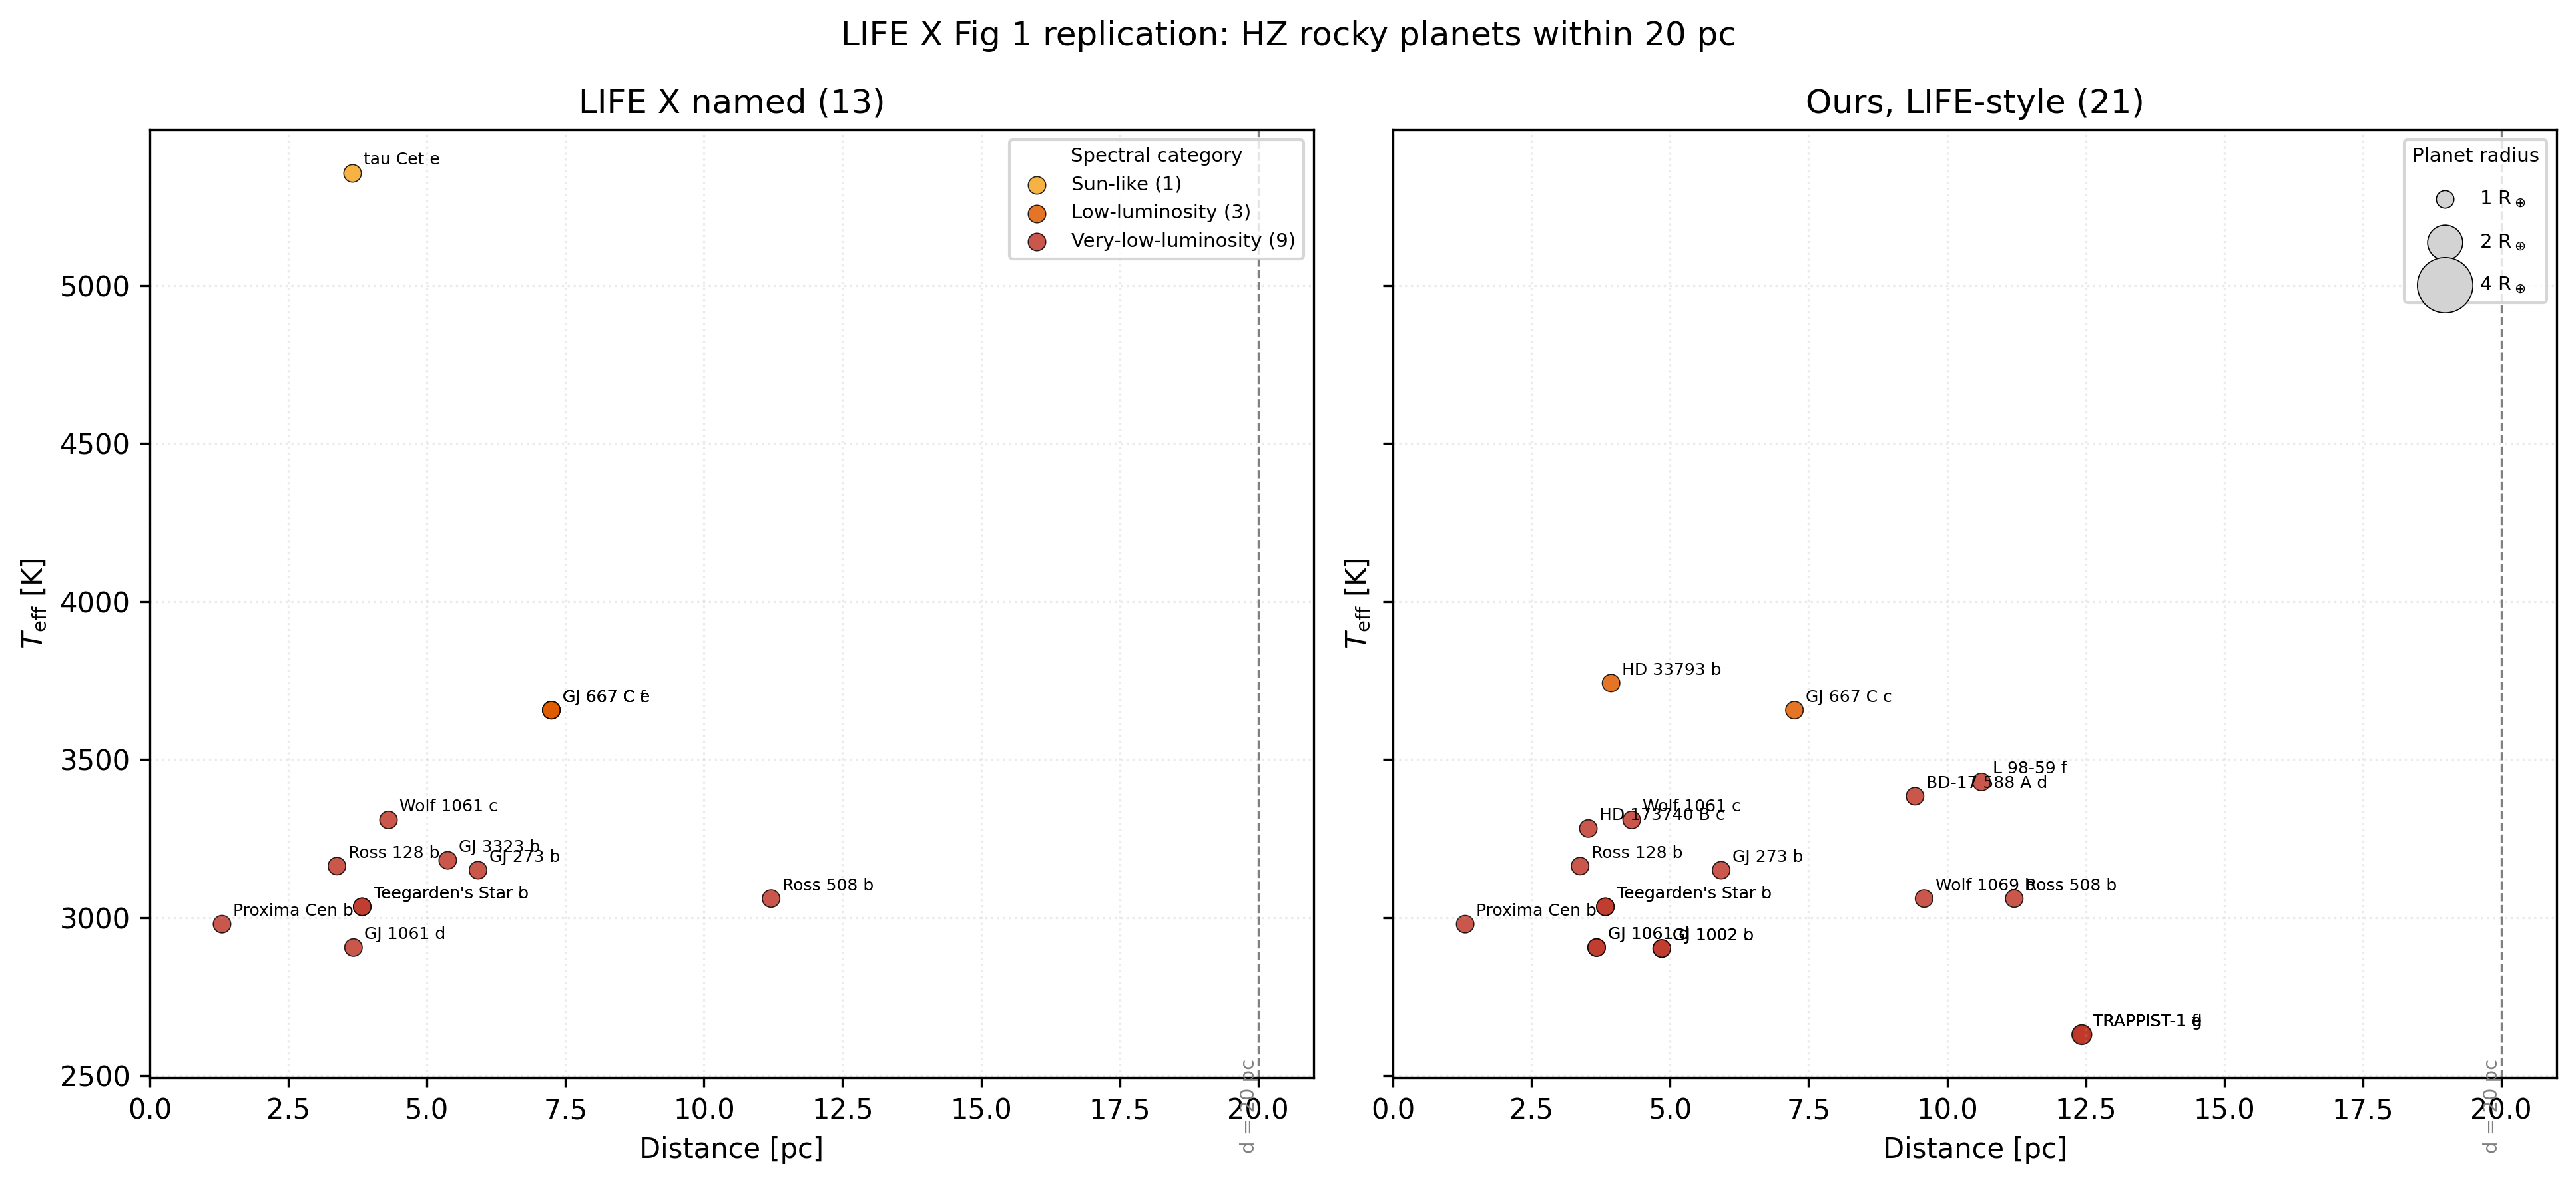

In [ ]:
# LIFE X Fig 1 style: distance vs Teff bubble plot.
# Left: the 13 LIFE X named M_p < 5 M_E HZ planets (host Teff/distance from full_emc).
# Right: our LIFE-style sample (life_hz_fc).
# Marker size scales with planet radius (rade_fc already uses msini->radius fallback in enrich()).
# Color = spectral_category (consistent palette).

# Build LIFE X panel by looking up each named planet in full_emc via normalize_name.
life_x_rows = []  # (name, teff, dist, rade, category)
for nm in LIFE_X_LIST:
    k = normalize_name(nm)
    idx = idx_all_fc.get(k)
    if idx is None:
        # Final fallback: scan emcn_fc / nasa_fc directly
        for j in range(len(full_emc)):
            if normalize_name(nasa_fc[j]) == k or normalize_name(emcn_fc[j]) == k:
                idx = j
                break
    if idx is None:
        print(f'  LIFE X planet not found in full_emc: {nm!r}')
        continue
    life_x_rows.append((
        nm,
        float(teff_fc[idx]),
        float(dist_fc[idx]),
        float(rade_fc[idx]) if rade_fc[idx] > 0 else np.nan,
        str(cats_fc[idx]),
    ))

# Our sample
our_idx = np.where(life_hz_fc)[0]
our_rows = [(name_fc[i], float(teff_fc[i]), float(dist_fc[i]),
             float(rade_fc[i]) if rade_fc[i] > 0 else np.nan,
             str(cats_fc[i])) for i in our_idx]

print(f'LIFE X panel: {len(life_x_rows)} / {len(LIFE_X_LIST)} planets located in full_emc')
print(f'Ours panel:   {len(our_rows)} planets')

# Marker size scaling: linear in radius, with sane defaults
def _size(rade):
    if not np.isfinite(rade) or rade <= 0:
        return 40.0  # fallback for radius-less planets
    return float(np.clip(40.0 * rade**2, 25.0, 400.0))

def _draw(ax, rows, title):
    for cat in CATEGORY_ORDER:
        xs = [d for (_, _, d, _, c) in rows if c == cat]
        ys = [t for (_, t, _, _, c) in rows if c == cat]
        ss = [_size(r) for (_, _, _, r, c) in rows if c == cat]
        if xs:
            ax.scatter(xs, ys, s=ss, color=CATEGORY_COLORS[cat],
                       edgecolor='black', linewidth=0.4, alpha=0.85,
                       label=f'{cat} ({len(xs)})')
    # Annotate every point
    for (nm, t, d, r, c) in rows:
        if np.isfinite(t) and np.isfinite(d):
            ax.annotate(nm, (d, t), xytext=(4, 3), textcoords='offset points',
                        fontsize=6, color='black')
    ax.axvline(20.0, color='gray', linestyle='--', linewidth=0.8)
    ax.text(20.0, ax.get_ylim()[0] if False else 0, '', fontsize=6)  # placeholder
    ax.set_xlim(0, 21)
    ax.set_xlabel('Distance [pc]')
    ax.set_ylabel(r'$T_\mathrm{eff}$ [K]')
    ax.set_title(title)
    ax.invert_yaxis()  # cooler stars at bottom (LIFE X Fig 1 convention)
    ax.grid(True, alpha=0.25, linestyle=':')

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
_draw(axL, life_x_rows, f'LIFE X named ({len(life_x_rows)})')
_draw(axR, our_rows,    f'Ours, LIFE-style ({len(our_rows)})')

# Add d=20 pc label on each panel
for ax in (axL, axR):
    y_top, y_bot = ax.get_ylim()  # inverted: y_top > y_bot
    ax.text(20.0, y_top - 0.02 * (y_top - y_bot), 'd = 20 pc',
            rotation=90, va='top', ha='right', fontsize=7, color='gray')

# Marker size legend (radius reference)
size_handles = []
for r_ref in (1.0, 2.0, 4.0):
    size_handles.append(plt.scatter([], [], s=_size(r_ref),
                                    color='lightgray', edgecolor='black',
                                    linewidth=0.4, label=rf'{r_ref:g} R$_\oplus$'))

# Spectral category legend from left panel; size legend separate
cat_handles, cat_labels = axL.get_legend_handles_labels()
leg1 = axL.legend(cat_handles, cat_labels, loc='upper right', fontsize=7,
                  title='Spectral category', title_fontsize=7)
axR.legend(handles=size_handles, loc='upper right', fontsize=7,
           title='Planet radius', title_fontsize=7, labelspacing=1.2)

fig.suptitle('LIFE X Fig 1 replication: HZ rocky planets within 20 pc')
plt.tight_layout()
plt.show()
